In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [7]:
temperaturas_df = pd.read_csv('temperatura-RJ.csv', skiprows=3,index_col='time' , parse_dates=True)
print(temperaturas_df)


            temperature_2m_mean (°C)
time                                
1979-01-01                      26.9
1979-01-02                      26.0
1979-01-03                      26.4
1979-01-04                      24.2
1979-01-05                      23.2
...                              ...
2025-06-26                      20.6
2025-06-27                      22.1
2025-06-28                      22.7
2025-06-29                      24.1
2025-06-30                      22.2

[16983 rows x 1 columns]


In [9]:
print('Dados nulos em temperatura:')
temperaturas_df.isna().sum()

Dados nulos em temperatura:


temperature_2m_mean (°C)    0
dtype: int64

In [12]:
print('Estatísticas básicas dos dados de temperatura:')
temperaturas_df.describe().round(2)

Estatísticas básicas dos dados de temperatura:


,temperature_2m_mean (°C)
count,16983.00
mean,23.80
std,2.71
min,15.30
25%,21.80
50%,23.80
75%,25.90
max,31.30


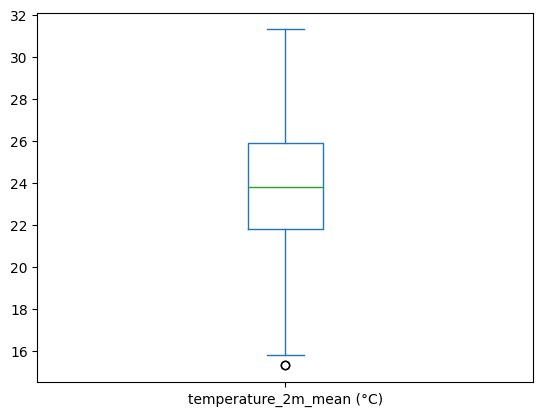

In [14]:
a= temperaturas_df.plot(kind='box')
plt.savefig('boxpl


In [16]:
print('Dia mais frio da história:')
DiaFrio = temperaturas_df.idxmin()
print(DiaFrio)

Dia mais frio da história:
temperature_2m_mean (°C)   1988-07-13
dtype: datetime64[ns]


In [17]:
print('Dia mais quente da história')
DiaQuente = temperaturas_df.idxmax()
print(DiaQuente)



Dia mais quente da história
temperature_2m_mean (°C)   2023-11-18
dtype: datetime64[ns]


<Axes: xlabel='time'>

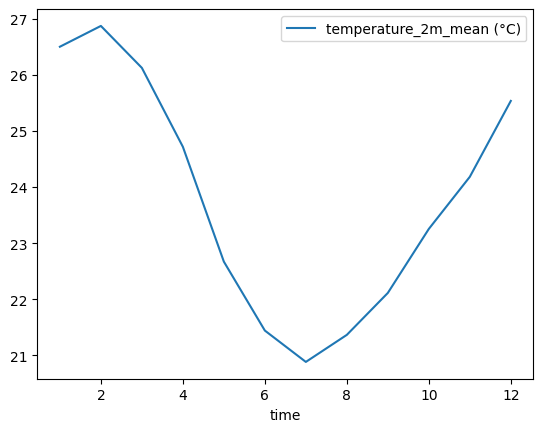

In [19]:
#Médias históricas mensais
medias_mensais = temperaturas_df.groupby(temperaturas_df.index.month).mean()
medias_mensais.plot()

<Axes: xlabel='time'>

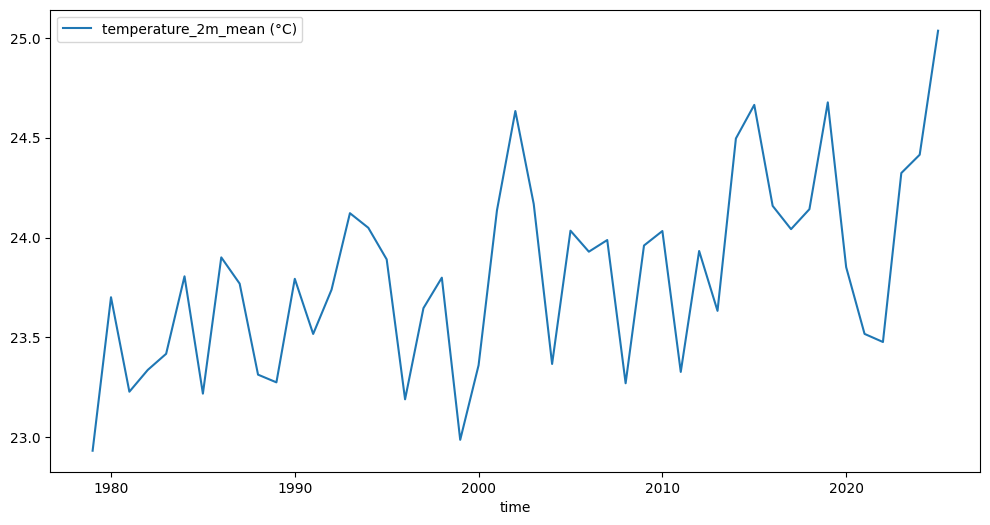

In [21]:
#Médias históricas anuais
medias_anuais = temperaturas_df.groupby(temperaturas_df.index.year).mean()
medias_anuais.plot(figsize=(12,6))

In [22]:
#Ano mais quente da história
medias_anuais.drop(2025).idxmax()

temperature_2m_mean (°C)    2019
dtype: int32

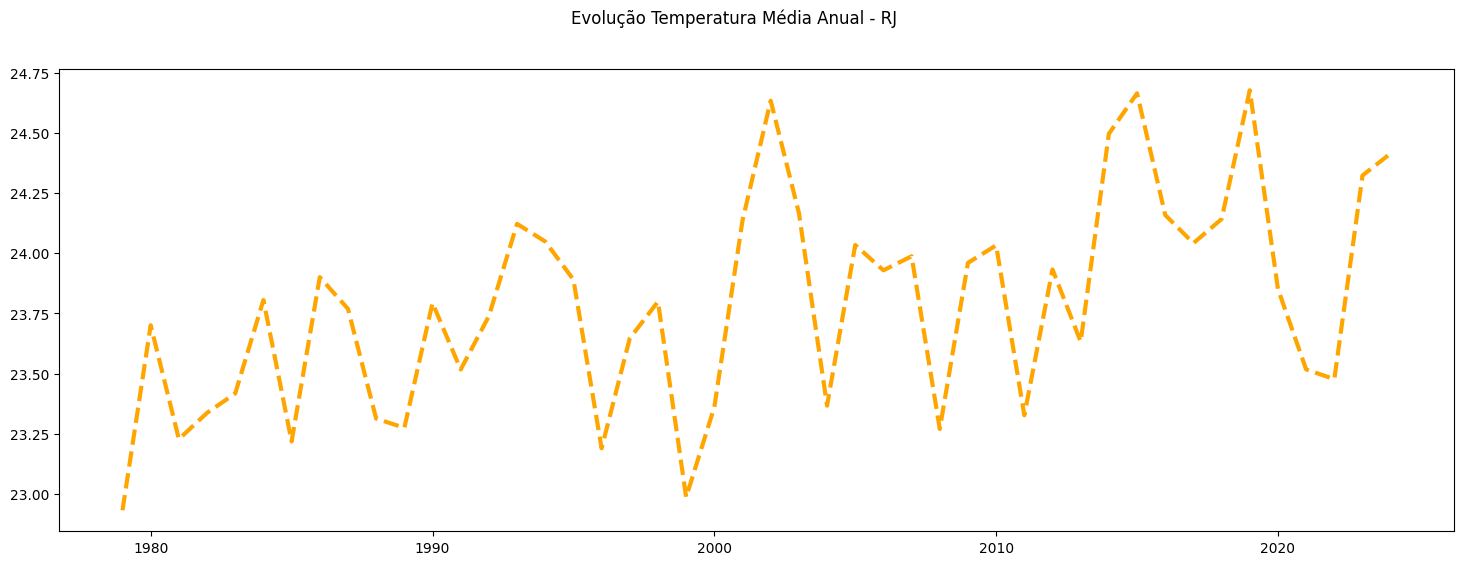

In [24]:
#Visualização de dados
dados_anuais = medias_anuais.drop(2025)
fig, ax = plt.subplots(figsize=(18,6))
fig.suptitle('Evolução Temperatura Média Anual - RJ')

#Plota gráfico de linha
ax.plot(dados_anuais, color= 'orange', lw=3, ls='--')
plt.savefig('temperatura_anual_rj.png')

In [25]:
# exportar os dados anuais para Excel
dados_anuais.to_excel('dados_temperatura_anual_rj.xlsx')